In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats



In [6]:
#prices1 = pd.read_csv('../prices_round_2_day_-1.csv', sep=';')
data= pd.read_csv("../prices_round_2_day_-1.csv", sep=";", index_col="timestamp")
#prices3 = pd.read_csv('../prices_round_2_day_1.csv', sep=';')

In [7]:
data

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,-1,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0
0,-1,ASH_COATED_OSMIUM,9982.0,21.0,NaN,NaN,NaN,NaN,10000.0,13.0,10003.0,21.0,NaN,NaN,9991.0,0.0
100,-1,ASH_COATED_OSMIUM,9984.0,15.0,NaN,NaN,NaN,NaN,10000.0,15.0,10003.0,26.0,NaN,NaN,9992.0,0.0
100,-1,INTARIAN_PEPPER_ROOT,10994.0,8.0,10991.0,22.0,NaN,NaN,11006.0,8.0,11009.0,22.0,NaN,NaN,11000.0,0.0
200,-1,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,30.0,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999700,-1,INTARIAN_PEPPER_ROOT,11993.0,11.0,NaN,NaN,NaN,NaN,12006.0,11.0,12009.0,23.0,NaN,NaN,11999.5,0.0
999800,-1,INTARIAN_PEPPER_ROOT,11993.0,9.0,11990.0,24.0,NaN,NaN,12006.0,9.0,NaN,NaN,NaN,NaN,11999.5,0.0
999800,-1,ASH_COATED_OSMIUM,9994.0,10.0,9992.0,27.0,NaN,NaN,10013.0,27.0,NaN,NaN,NaN,NaN,10003.5,0.0


In [8]:
pepper = data.query("product == 'INTARIAN_PEPPER_ROOT'")
osmium = data.query("product == 'ASH_COATED_OSMIUM'")




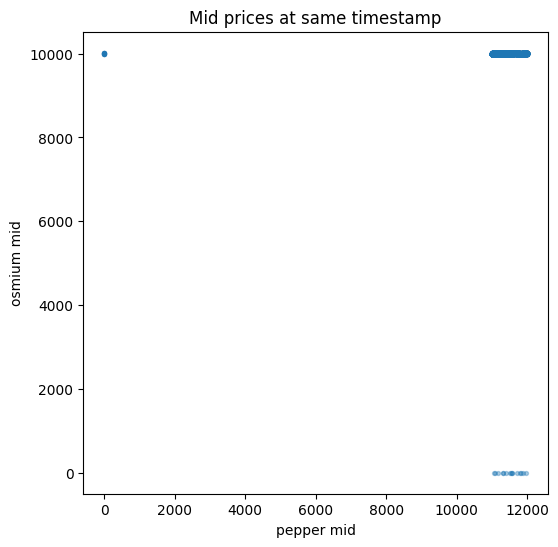

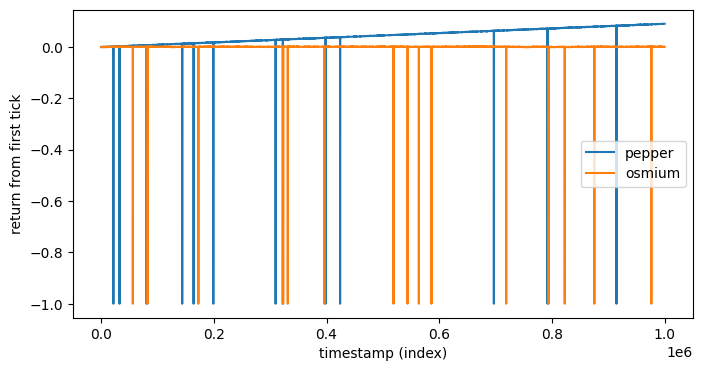

In [15]:
p = pepper[["mid_price"]].rename(columns={"mid_price": "pepper_mid"})
o = osmium[["mid_price"]].rename(columns={"mid_price": "osmium_mid"})
m = p.join(o, how="inner")

# Separate figures — otherwise the 2nd plot reuses the same axes and rescales,
# making the scatter (10k-scale) invisible.

fig1, ax1 = plt.subplots(figsize=(6, 6))
ax1.scatter(m["pepper_mid"], m["osmium_mid"], alpha=0.35, s=8)
ax1.set_xlabel("pepper mid")
ax1.set_ylabel("osmium mid")
ax1.set_title("Mid prices at same timestamp")
plt.show()


def norm(s):
    return (s - s.iloc[0]) / s.iloc[0]


fig2, ax2 = plt.subplots(figsize=(8, 4))
norm(pepper.mid_price).plot(ax=ax2, label="pepper")
norm(osmium.mid_price).plot(ax=ax2, label="osmium")
ax2.legend()
ax2.set_ylabel("return from first tick")
ax2.set_xlabel("timestamp (index)")
plt.show()

C:\Users\ATM Rahat Hossain\AppData\Local\Temp\ipykernel_26600\3859609779.py:5: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  pepper.spread = pepper.ask_price_1 - pepper.bid_price_1


<Axes: xlabel='timestamp'>

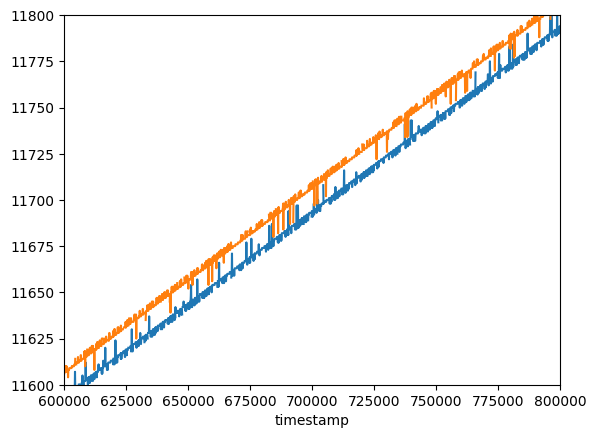

In [ ]:
pepper.bid_price_1.plot()
pepper.ask_price_1.plot()
plt.xlim(600000, 800000)
plt.ylim(11600, 11800)


<Axes: >

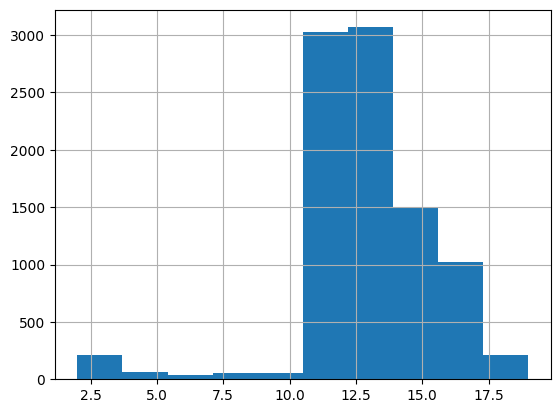

In [55]:
pepper.spread.dropna().hist()


